# Initialize the instrument

In [1]:
from Equipments import BNC575
from Equipments import Weeder
from Equipments import SR400
from Equipments import MCBOX
from Equipments import Andor
import numpy as np
import matplotlib.pyplot as plt
import pyvisa
import time

In [2]:
from DataProcessing.Plot import PlotSaver

In [3]:
ps = PlotSaver("X:\\migratedData\\Rydberg_QIS\\data")

In [12]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'GPIB0::9::INSTR', 'GPIB0::23::INSTR')


In [13]:
bnc575 = BNC575.BNC575("GPIB0::9::INSTR")

In [14]:
sr400 = SR400.SR400('GPIB0::23::INSTR',timeout=1000)

In [15]:
weeder = Weeder.Weeder("ASRL1::INSTR")

In [16]:
mcbox = MCBOX.MCBOX(find_device = "USB-3114")

USB-3114 found.
Board number: 0


# Define the pulse

In [9]:
pulse_arrangement = [["A", 900e-6, 0, "TTL"],   # MOT
                     [["B", 10e-6, 5e-6, 15],    # 780 excitation 20dB attenuator connected
                      ["C", 10e-6, 5e-6, "TTL"]],    # 480 exc
                     ["D", 20e-6, 0, 8],        # DEI switch
                    ]
T = 1000e-6

cycle_number = 30
# photon counter gate width
gate_width = 15e-6
gate_delay = 3e-6

In [10]:
sr400.counter_set(count_mode = "INDEPENDENT", count_preset = 100e-6, count_period_num=cycle_number, dwell=0, sourceA="INPUT1",sourceB="INPUT2", gate_A_mode="FIXED", gate_A_delay=gate_delay,
                gate_A_width=gate_width,gate_B_mode="CW")

---------------------------------------
The photon counter is now set to:

Counting Mode: INDEPENDENT
T Input: 10MHz
T Preset: 0.0001s
Period number: 30
Dwell time: External
Counter A source: INPUT1
Counter B source: INPUT2

The gate A is set to:

Delay: 3.000E-6
Width: 15.00E-6


The gate B is set to: CW
---------------------------------------


In [17]:
bnc575.clock_set(period=T,mode="CONTINUOUS")
bnc575.pulse_sequence_setup(pulse_arrangement)

---------------------------------------
The global clock is set to:
Mode: NORM
Period: 1.00e-03s
Pulses number: N/A
---------------------------------------
[['A', 0.0009, 0, 'TTL'], ['B', 1e-05, 0.000905, 15], ['C', 1e-05, 0.000905, 'TTL'], ['D', 2e-05, 0.000915, 8]]
---------------------------------------
The channel A is set to:
Width: 9.0000e-04s
Delay: 0.0000e+00s
Synchronize to: T0
Out: TTL

Output timers:
HGFEDCBA
00000001
---------------------------------------
---------------------------------------
The channel B is set to:
Width: 1.0000e-05s
Delay: 9.0500e-04s
Synchronize to: T0
Out: 15.00

Output timers:
HGFEDCBA
00000010
---------------------------------------
---------------------------------------
The channel C is set to:
Width: 1.0000e-05s
Delay: 9.0500e-04s
Synchronize to: T0
Out: TTL

Output timers:
HGFEDCBA
00000100
---------------------------------------
---------------------------------------
The channel D is set to:
Width: 2.0000e-05s
Delay: 9.1500e-04s
Synchronize 

In [18]:
bnc575.start_pulses()

# Search the resonance

In [21]:
weeder.position(header = "A", query = True)

'A3423'

In [54]:
weeder.move("A", position = 3400, progress = True)

start at 3100 --> 3400.0 --> 3400
Old position: 3100
New position: 3400


In [44]:
weeder.advance(header = "A", num_step = -10)

start at 3360 --> 3350.0 --> 3350
Old position: 3360
New position: 3350


# Stark map

## Scan parameters

In [22]:
center = 3360
stride = 1
half_width = 200


# scan list gneration
x_list = np.arange(2* half_width/stride)

In [58]:
# everytime go further and go back to release the band tension and gear margin
start_position = center - half_width
weeder.move(header = "A", position = start_position-100)
weeder.move(header = "A", position = start_position)

results = []
s = time.time()
for idx in x_list:
    print(f"now checking step: {idx}", end = "\r", flush=True)
    sr400.count_reset()
    time.sleep(0.1)
    result = np.mean(sr400.read_entire_counts(counter="A",length = cycle_number))
    results.append(result)
    for i in range(stride):
        weeder.step("A","+")
    time.sleep(0.1)
e = time.time()
print(e-s)

start at 3560 --> 3060.0 --> 3060
Old position: 3560
New position: 3060
start at 3060 --> 3160.0 --> 3160
Old position: 3060
New position: 3160
now checking step: 0.0
One entire measurement is done, the last count is 0
now checking step: 1.0
One entire measurement is done, the last count is 0
now checking step: 2.0
One entire measurement is done, the last count is 0
now checking step: 3.0
One entire measurement is done, the last count is 0
now checking step: 4.0
One entire measurement is done, the last count is 0
now checking step: 5.0
One entire measurement is done, the last count is 0
now checking step: 6.0
One entire measurement is done, the last count is 0
now checking step: 7.0
One entire measurement is done, the last count is 0
now checking step: 8.0
One entire measurement is done, the last count is 0
now checking step: 9.0
One entire measurement is done, the last count is 0
now checking step: 10.0
One entire measurement is done, the last count is 0
now checking step: 11.0
One en

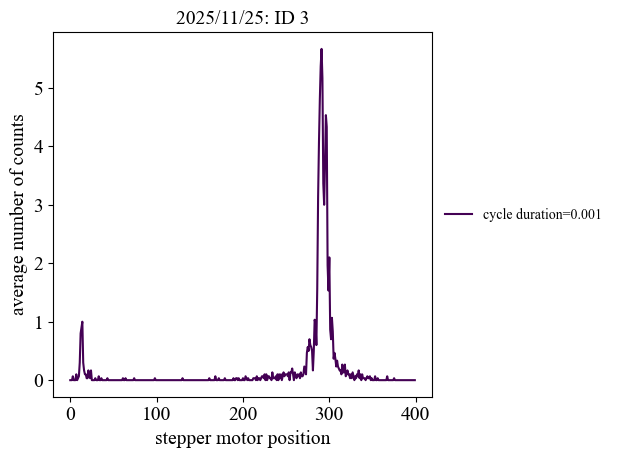

In [59]:
ps.Plot2D(x = x_list*stride, y = T, Z = results, xlabel = "stepper motor position", ylabel = "cycle duration", zlabel = "average number of counts")

## 2D

In [23]:
center = 3360
stride = 1
half_width = 200


# scan list gneration
x_list = np.arange(2* half_width/stride)

In [24]:
start_position = center - half_width

v_list = np.linspace(-1,1,11)
stark_map = []
for v in v_list:
    mcbox.set_voltage_1chan(board_num = 0, channel = 10, voltage = v, bipolar = True)
    mcbox.set_voltage_1chan(board_num = 0, channel = 11, voltage = -v, bipolar = True)
    
    # everytime go further and go back to release the band tension and gear margin
    weeder.move(header = "A", position = start_position-100)
    weeder.move(header = "A", position = start_position)
    results = []
    for idx in x_list:
        print(f"now checking step: {idx}", end = "\r", flush=True)
        sr400.count_reset()
        time.sleep(0.005)
        result = np.mean(sr400.read_entire_counts(counter="A",length = cycle_number))
        results.append(result)
        for i in range(stride):
            weeder.step("A","+")
        time.sleep(0.005)
    stark_map.append(results)

Channel 10 has been set to -1.0 V.
Channel 11 has been set to 1.0 V.
start at 3423 --> 3060.0 --> 3060
Old position: 3423
New position: 3061
start at 3061 --> 3160.0 --> 3160
Old position: 3061
New position: 3160
Channel 10 has been set to -0.8 V.
Channel 11 has been set to 0.8 V.
start at 3560 --> 3060.0 --> 3060
Old position: 3560
New position: 3060
start at 3060 --> 3160.0 --> 3160
Old position: 3060
New position: 3160
Channel 10 has been set to -0.6 V.
Channel 11 has been set to 0.6 V.
start at 3560 --> 3060.0 --> 3060
Old position: 3560
New position: 3060
start at 3060 --> 3160.0 --> 3160
Old position: 3060
New position: 3160
Channel 10 has been set to -0.3999999999999999 V.
Channel 11 has been set to 0.3999999999999999 V.
start at 3560 --> 3060.0 --> 3060
Old position: 3560
New position: 3060
start at 3060 --> 3160.0 --> 3160
Old position: 3060
New position: 3160
Channel 10 has been set to -0.19999999999999996 V.
Channel 11 has been set to 0.19999999999999996 V.
start at 3560 -->

In [21]:
mcbox.set_voltage_1chan(board_num = 0, channel = 11, voltage = 0, bipolar = True)

Channel 11 has been set to 0 V.


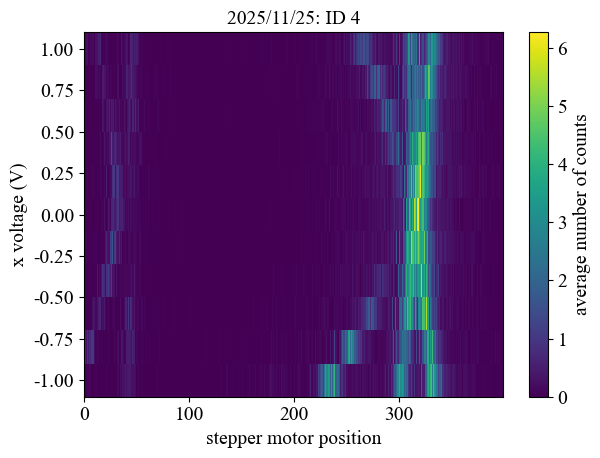

In [25]:
ps.Plot3D(x = x_list*stride, y = v_list, Z = stark_map, xlabel = "stepper motor position", ylabel = "x voltage (V)", zlabel = "average number of counts")

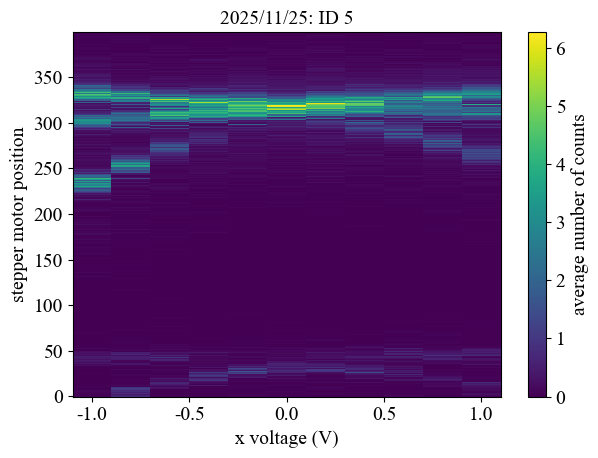

In [26]:
ps.Plot3D(x = v_list , y = x_list*stride, Z = np.array(stark_map).T, xlabel = "x voltage (V)", ylabel = "stepper motor position", zlabel = "average number of counts")